In [3]:
# ==========================================
# Car Selling Price Prediction
# Import Required Libraries
# ==========================================

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import warnings
warnings.filterwarnings('ignore')

#upload the dataset

from google.colab import files

uploaded = files.upload()

Saving car.csv to car.csv


In [4]:
df = pd.read_csv("car.csv")

df.head()

print("Dataset Shape :", df.shape)
df.info()
df.describe()
df.isnull().sum()

Dataset Shape : (301, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Kms_Driven     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Seller_Type    301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


,0
Car_Name,0
Year,0
Selling_Price,0
Present_Price,0
Kms_Driven,0
Fuel_Type,0
Seller_Type,0
Transmission,0
Owner,0


In [5]:
# Check duplicate rows

print("Duplicate Rows:", df.duplicated().sum())

df.drop_duplicates(inplace=True)

print("Dataset Shape:", df.shape)

Duplicate Rows: 2
Dataset Shape: (299, 9)


In [6]:
df.isnull().sum()

,0
Car_Name,0
Year,0
Selling_Price,0
Present_Price,0
Kms_Driven,0
Fuel_Type,0
Seller_Type,0
Transmission,0
Owner,0


In [7]:
#convert names into numbers because Model cannot understand direct names its called as encoding

print(df["Fuel_Type"].unique())

print(df["Seller_Type"].unique())

print(df["Transmission"].unique())

['Petrol' 'Diesel' 'CNG']
['Dealer' 'Individual']
['Manual' 'Automatic']


In [8]:
# One-Hot Encoding

df = pd.get_dummies(
    df,
    columns=["Fuel_Type","Seller_Type","Transmission"],
    drop_first=True
)

df.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Owner,Fuel_Type_Diesel,Fuel_Type_Petrol,Seller_Type_Individual,Transmission_Manual
0,ritz,2014,3.35,5.59,27000,0,False,True,False,True
1,sx4,2013,4.75,9.54,43000,0,True,False,False,True
2,ciaz,2017,7.25,9.85,6900,0,False,True,False,True
3,wagon r,2011,2.85,4.15,5200,0,False,True,False,True
4,swift,2014,4.60,6.87,42450,0,True,False,False,True


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 299 entries, 0 to 300
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Car_Name                299 non-null    object 
 1   Year                    299 non-null    int64  
 2   Selling_Price           299 non-null    float64
 3   Present_Price           299 non-null    float64
 4   Kms_Driven              299 non-null    int64  
 5   Owner                   299 non-null    int64  
 6   Fuel_Type_Diesel        299 non-null    bool   
 7   Fuel_Type_Petrol        299 non-null    bool   
 8   Seller_Type_Individual  299 non-null    bool   
 9   Transmission_Manual     299 non-null    bool   
dtypes: bool(4), float64(2), int64(3), object(1)
memory usage: 17.5+ KB


In [10]:
df.drop("Car_Name", axis=1, inplace=True)

df.head()

,Year,Selling_Price,Present_Price,Kms_Driven,Owner,Fuel_Type_Diesel,Fuel_Type_Petrol,Seller_Type_Individual,Transmission_Manual
0,2014,3.35,5.59,27000,0,False,True,False,True
1,2013,4.75,9.54,43000,0,True,False,False,True
2,2017,7.25,9.85,6900,0,False,True,False,True
3,2011,2.85,4.15,5200,0,False,True,False,True
4,2014,4.60,6.87,42450,0,True,False,False,True


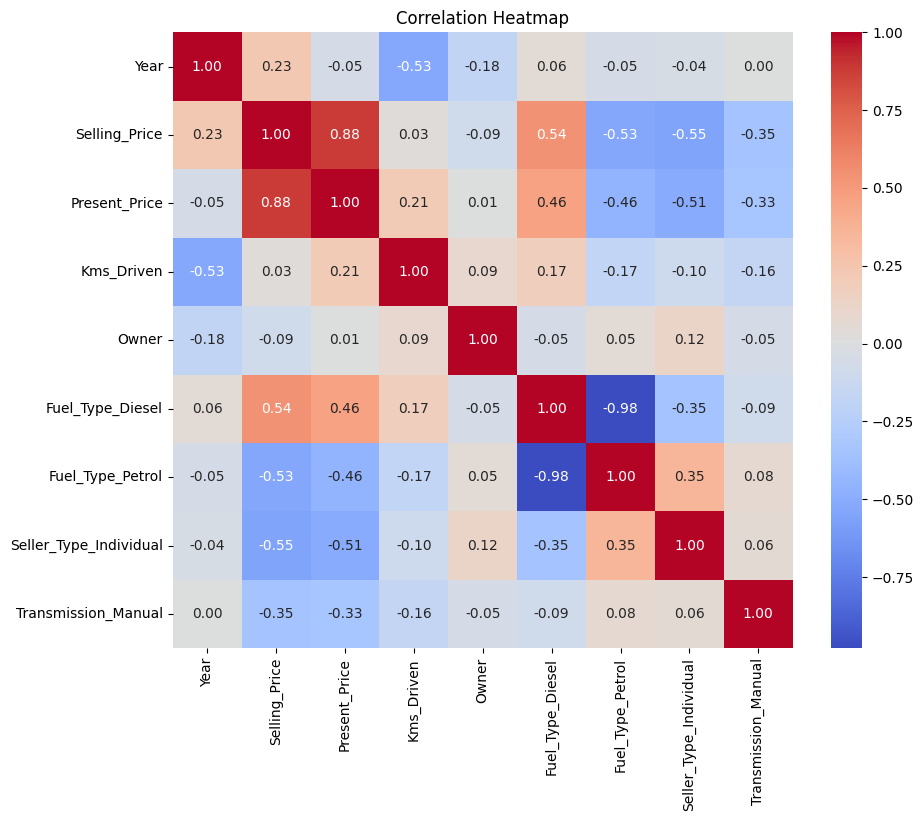

In [11]:
#EDA

plt.figure(figsize=(10,8))

sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Correlation Heatmap")

plt.show()

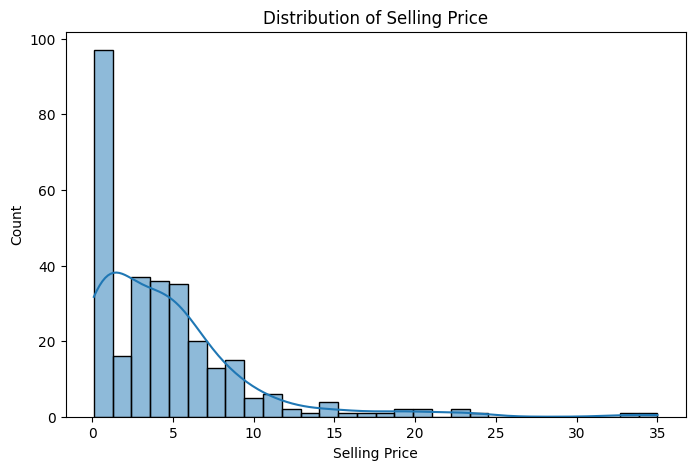

In [12]:
plt.figure(figsize=(8,5))

sns.histplot(df["Selling_Price"], bins=30, kde=True)

plt.title("Distribution of Selling Price")

plt.xlabel("Selling Price")

plt.ylabel("Count")

plt.show()

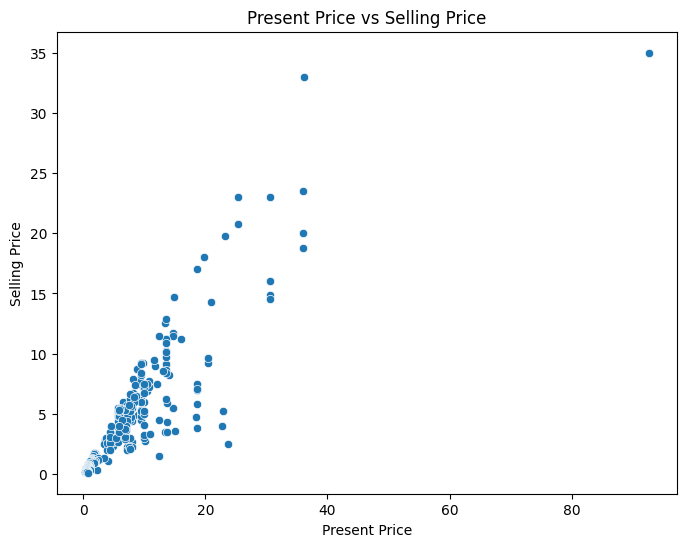

In [13]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=df["Present_Price"],
    y=df["Selling_Price"]
)

plt.title("Present Price vs Selling Price")

plt.xlabel("Present Price")

plt.ylabel("Selling Price")

plt.show()

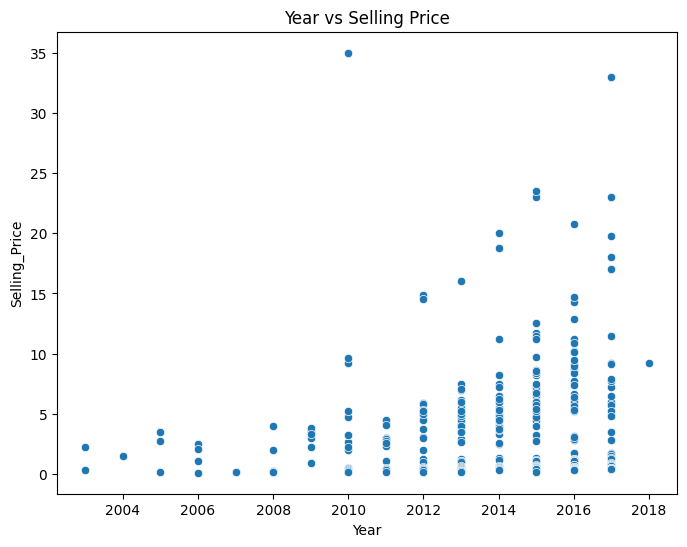

In [14]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=df["Year"],
    y=df["Selling_Price"]
)

plt.title("Year vs Selling Price")

plt.show()

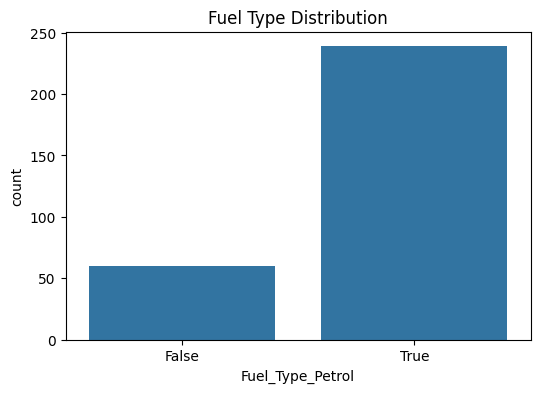

In [15]:
plt.figure(figsize=(6,4))

sns.countplot(x="Fuel_Type_Petrol", data=df)

plt.title("Fuel Type Distribution")

plt.show()

In [16]:
# Features
X = df.drop("Selling_Price", axis=1)

# Target
y = df["Selling_Price"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)

Training Data Shape: (239, 8)
Testing Data Shape: (60, 8)


In [17]:
model = LinearRegression()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

comparison = pd.DataFrame({
    "Actual Price": y_test,
    "Predicted Price": y_pred
})

comparison.head(10)

,Actual Price,Predicted Price
283,8.99,7.501922
267,8.35,7.791521
166,0.45,1.366444
9,7.45,7.009419
78,5.25,11.163290
280,5.25,4.534102
95,5.85,8.492463
111,1.15,1.700782
5,9.25,8.824220
175,0.38,-0.963488


In [18]:
# ==========================================
# Model Evaluation
# ==========================================

mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error (MAE):", round(mae,2))
print("Mean Squared Error (MSE):", round(mse,2))
print("Root Mean Squared Error (RMSE):", round(rmse,2))
print("R² Score:", round(r2,2))

Mean Absolute Error (MAE): 1.47
Mean Squared Error (MSE): 6.37
Root Mean Squared Error (RMSE): 2.52
R² Score: 0.75


In [19]:
evaluation = pd.DataFrame({
    "Metric": ["MAE", "MSE", "RMSE", "R² Score"],
    "Value": [mae, mse, rmse, r2]
})

evaluation

,Metric,Value
0,MAE,1.472892
1,MSE,6.370753
2,RMSE,2.524035
3,R² Score,0.752815


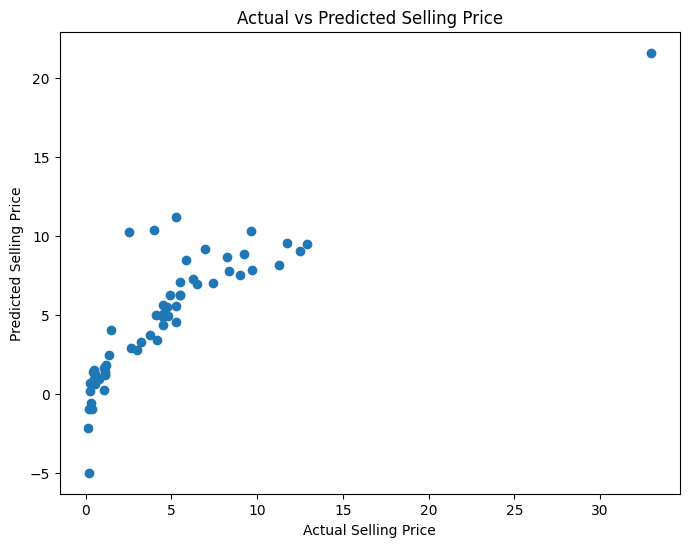

In [20]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Selling Price")

plt.ylabel("Predicted Selling Price")

plt.title("Actual vs Predicted Selling Price")

plt.show()

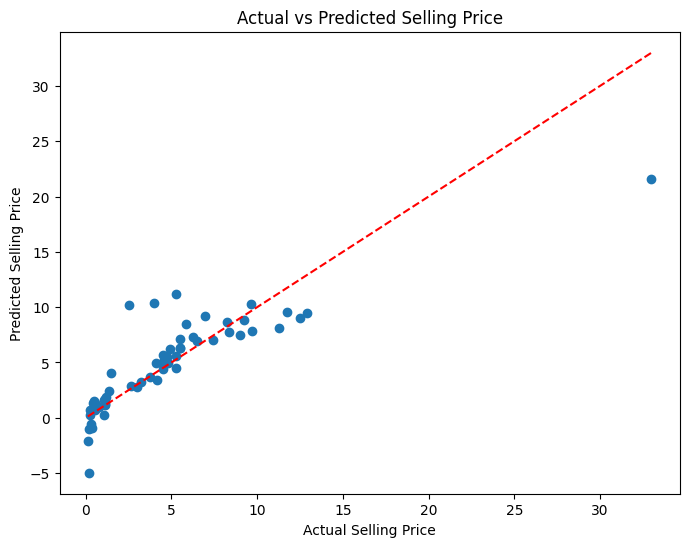

In [21]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.xlabel("Actual Selling Price")

plt.ylabel("Predicted Selling Price")

plt.title("Actual vs Predicted Selling Price")

plt.show()

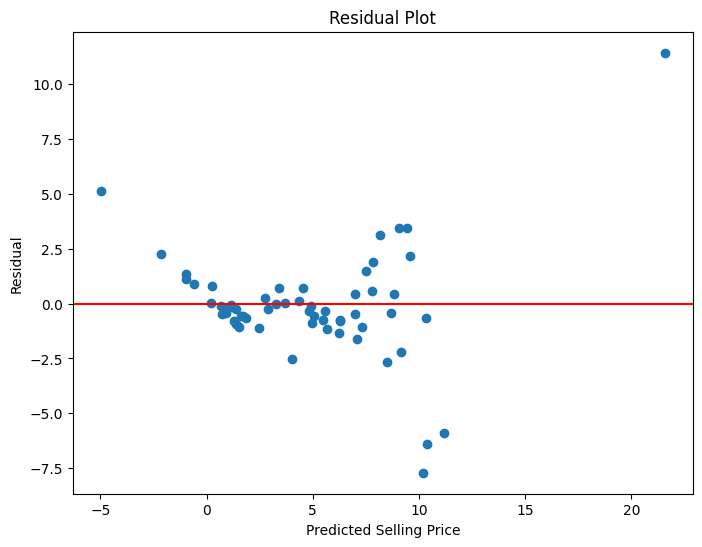

In [22]:
residuals = y_test - y_pred

plt.figure(figsize=(8,6))

plt.scatter(y_pred, residuals)

plt.axhline(y=0, color='red')

plt.xlabel("Predicted Selling Price")

plt.ylabel("Residual")

plt.title("Residual Plot")

plt.show()

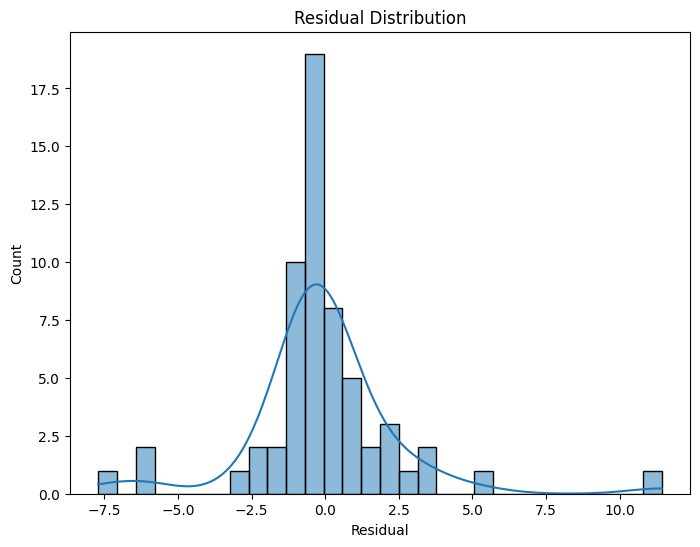

In [23]:
plt.figure(figsize=(8,6))

sns.histplot(residuals, bins=30, kde=True)

plt.title("Residual Distribution")

plt.xlabel("Residual")

plt.show()

In [24]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

coefficients.sort_values(by="Coefficient", ascending=False)

,Feature,Coefficient
4,Fuel_Type_Diesel,2.139111
5,Fuel_Type_Petrol,0.690622
3,Owner,0.642856
1,Present_Price,0.437187
0,Year,0.331041
2,Kms_Driven,-0.000011
6,Seller_Type_Individual,-1.301377
7,Transmission_Manual,-1.572125


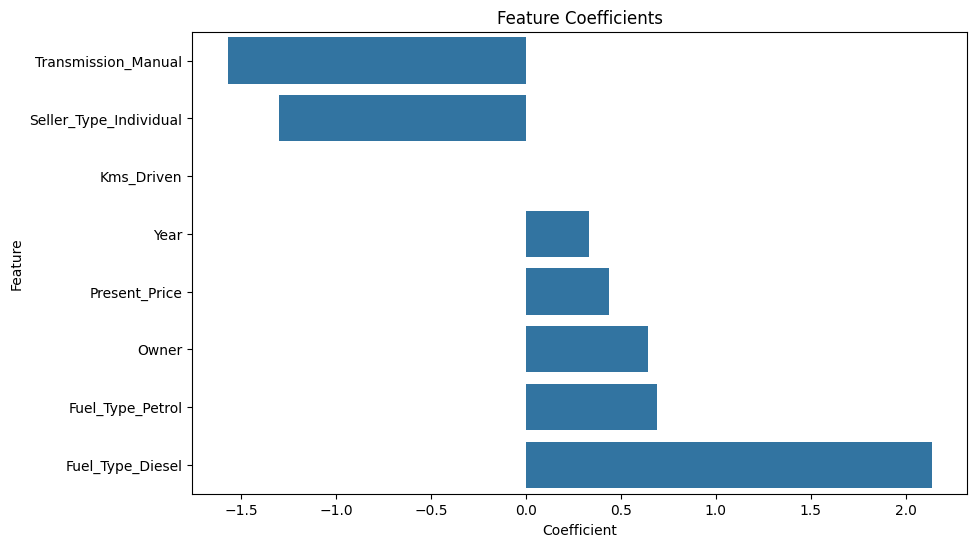

In [25]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=coefficients.sort_values(by="Coefficient"),
    x="Coefficient",
    y="Feature"
)

plt.title("Feature Coefficients")

plt.show()

In [26]:
sample_car = [[
    2020,    # Year
    8.5,     # Present Price
    25000,   # Kms Driven
    1,       # Fuel_Type_Diesel
    0,       # Fuel_Type_Petrol
    0,       # Seller_Type_Individual (0 = Dealer)
    1,       # Transmission_Manual
    0        # Owner
]]

predicted_price = model.predict(sample_car)

print("Predicted Selling Price:", round(predicted_price[0],2))

Predicted Selling Price: 7.44


In [28]:
import joblib

joblib.dump(model, "Car_Selling_Price_Model.pkl")

print("Model saved successfully!")

Model saved successfully!


In [29]:
loaded_model = joblib.load("Car_Selling_Price_Model.pkl")

print("Model loaded successfully!")

Model loaded successfully!


In [30]:
print("="*60)
print("      CAR SELLING PRICE PREDICTION")
print("="*60)

print(f"Dataset Shape       : {df.shape}")
print(f"Training Samples    : {X_train.shape[0]}")
print(f"Testing Samples     : {X_test.shape[0]}")
print(f"Number of Features  : {X.shape[1]}")

print("\nModel Used          : Linear Regression")

print("\nEvaluation Metrics")
print("----------------------")
print(f"MAE       : {mae:.2f}")
print(f"MSE       : {mse:.2f}")
print(f"RMSE      : {rmse:.2f}")
print(f"R² Score  : {r2:.2f}")

print("="*60)
print("Project Completed Successfully")
print("="*60)

      CAR SELLING PRICE PREDICTION
Dataset Shape       : (299, 9)
Training Samples    : 239
Testing Samples     : 60
Number of Features  : 8

Model Used          : Linear Regression

Evaluation Metrics
----------------------
MAE       : 1.47
MSE       : 6.37
RMSE      : 2.52
R² Score  : 0.75
Project Completed Successfully


# Conclusion

In this project, a Linear Regression model was developed to predict the selling price of used cars based on features such as manufacturing year, present showroom price, kilometers driven, fuel type, seller type, transmission type, and number of previous owners. The dataset was preprocessed by encoding categorical variables and removing unnecessary features. The model was trained using an 80:20 train-test split and evaluated using Mean Absolute Error (MAE), Mean Squared Error (MSE), Root Mean Squared Error (RMSE), and R² Score. The results show that the model can effectively estimate the selling price of used cars, demonstrating the application of supervised machine learning for regression tasks.
